# Lab — Kernel Methods
## Where are the expensive houses in California?

## Part 1 — The problem

In [1]:
DATA_URL     = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
N_SAMPLE     = 3000
RANDOM_STATE = 42
TEST_SIZE    = 0.3                                          # stratified split
FEATURES     = ["longitude", "latitude", "median_income"]   # income only in Part 7
# y = +1 (C0, expensive) if median_house_value > median of the full dataset, else -1 (C1)
# Inputs standardised with a scaler fitted on the training set

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


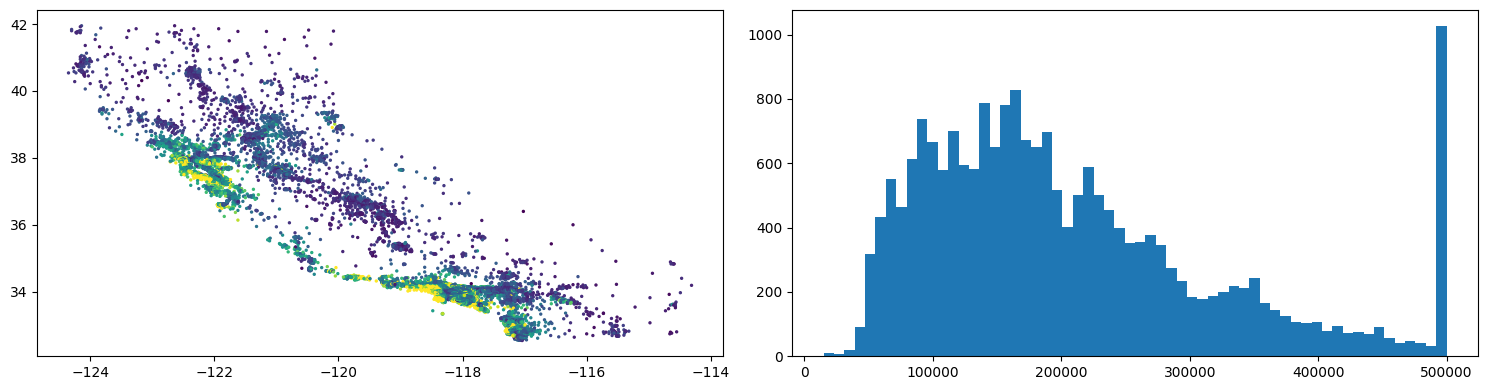

In [4]:
fig, axes = plt.subplots(1,2, figsize= (15,4))

axes[0].scatter(df.longitude, df.latitude, s = 2 , c= df.median_house_value)
axes[1].hist(df.median_house_value, bins = 60)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision(predict_fn, ax=None, title="", support_idx=None, resolution=220):
    # Needs: X_train (unscaled, cols 0-1 = lon, lat), y_train (+1/-1), scaler (fitted on X_train)
    # predict_fn receives scaled coordinates and returns +1/-1
    ax = ax or plt.gca()
    lon = np.linspace(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5, resolution)
    lat = np.linspace(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5, resolution)
    grid_lon, grid_lat = np.meshgrid(lon, lat)
    grid = (np.c_[grid_lon.ravel(), grid_lat.ravel()] - scaler.mean_[:2]) / scaler.scale_[:2]

    Z = np.concatenate([predict_fn(grid[i:i + 5000])
                        for i in range(0, len(grid), 5000)]).reshape(grid_lon.shape)
    ax.contourf(grid_lon, grid_lat, Z, levels=[-2, 0, 2], colors=["#9ecae1", "#fdae6b"], alpha=0.6)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=4)
    if support_idx is not None:
        ax.scatter(X_train[support_idx, 0], X_train[support_idx, 1],
                   s=14, facecolors="none", edgecolors="k", linewidths=0.5)
    ax.set(title=title, xlabel="longitude", ylabel="latitude")
    ax.set_aspect("equal")
    return ax

In [6]:
data = df.sample(3000)
FEATURES =  ["longitude", "latitude", "median_income"]

X = data[FEATURES].values

threshold = df.median_house_value.median()

y = np.where(data.median_house_value > threshold, 1, -1)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(X_train)

Xtr_all, Xte_all = scaler.transform(X_train), scaler.transform(X_test)

Xtr, Xte = Xtr_all[:,:2], Xte_all[:,:2]

In [7]:
print(X_train.shape)
print(Xtr.shape)

(2100, 3)
(2100, 2)


## Part 2 — Linear classifiers

<Axes: title={'center': 'SVM: 0.747'}, xlabel='longitude', ylabel='latitude'>

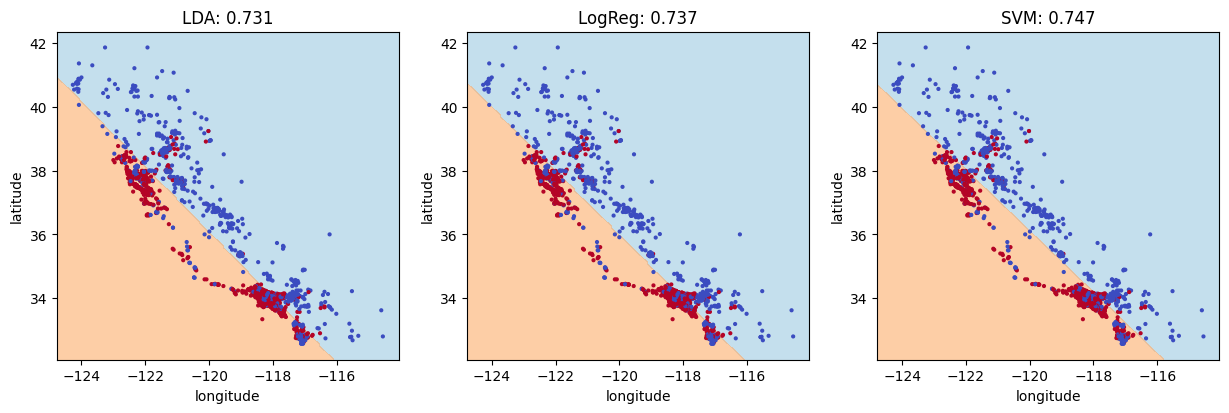

In [8]:
# LDA 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

m1 = LinearDiscriminantAnalysis()
m1.fit(Xtr, y_train)

fig, axes = plt.subplots(1,3, figsize = (15,5))
plot_decision(m1.predict, axes[0], title = f"LDA: {m1.score(Xte, y_test):.3f}")

from sklearn.linear_model import LogisticRegression

m2 = LogisticRegression()
m2.fit(Xtr, y_train)

plot_decision(m2.predict, axes[1], title = f"LogReg: {m2.score(Xte, y_test):.3f}")

from sklearn.svm import SVC

m3 = SVC(C= 1.0,kernel= "linear")
m3.fit(Xtr, y_train)

plot_decision(m3.predict, axes[2], title = f"SVM: {m3.score(Xte, y_test):.3f}")

## Part 3 — Explicit feature maps vs. the kernel trick

$$\phi(\mathbf{x}) = (1, x_1, x_2, x_1^2, x_1x_2, \dots, x_2^d) \qquad\text{vs.}\qquad k(\mathbf{x},\mathbf{z}) = (\mathbf{x}^\top\mathbf{z}+1)^d$$

In [9]:
DEGREES = [1, 2, 3, 5, 8]
C       = 1
from sklearn.preprocessing import PolynomialFeatures

# ms = []
# accs = []
# for d in DEGREES:
#     poly = PolynomialFeatures(degree=d, include_bias=False)
#     Xtr_poly = poly.fit_transform(Xtr)
#     Xte_poly = poly.transform(Xtr)
#     print(Xtr_poly.shape)

#     svm2 = SVC(C= 1.0,kernel= "linear")
#     svm2.fit(Xtr_poly, y_train)

#     plot_decision(m3.predict, axes[2])
#     # accuracies
    
#     ms.append(svm2.fit(Xtr_poly, y_train).score(Xte_poly, y_test))
    
# #kernel trick

In [10]:
from math import comb
DEGREES = [1, 2, 3, 5, 8]
C       = 1
from sklearn.preprocessing import PolynomialFeatures

rows = []
for d in DEGREES:
    phi = PolynomialFeatures(d)
    Phi_tr, Phi_te = phi.fit_transform(Xtr), phi.transform(Xte)
    acc = SVC(kernel="linear", C=C).fit(Phi_tr, y_train).score(Phi_te, y_test)
    rows.append((d, Phi_tr.shape[1], comb(2+d,d), acc))
pd.DataFrame(rows, columns= ["d", "dim H (data)", "C(n+d, d)", "test_acc"])
    



,d,dim H (data),"C(n+d, d)",test_acc
0,1,3,3,0.746667
1,2,6,6,0.746667
2,3,10,10,0.733333
3,5,21,21,0.757778
4,8,45,45,0.770000


In [11]:
DEGREES = [1, 2, 3, 5, 8]
rows = []

for d in DEGREES:
    model = SVC(kernel="poly",degree=d, gamma=1 , coef0=1).fit(Xtr, y_train)
    acc = model.score(Xte, y_test)
    # rows.append((d, Xtr.shape[1], comb(2+d,d), acc))
    print(d,acc)
# pd.DataFrame(rows, columns= ["d", "dim H (data)", "C(n+d, d)", "test_acc"])


1 0.7466666666666667
2 0.7455555555555555
3 0.7422222222222222
5 0.7488888888888889
8 0.7655555555555555


In [12]:
model.support_

array([   6,   10,   12, ..., 2086, 2090, 2091])

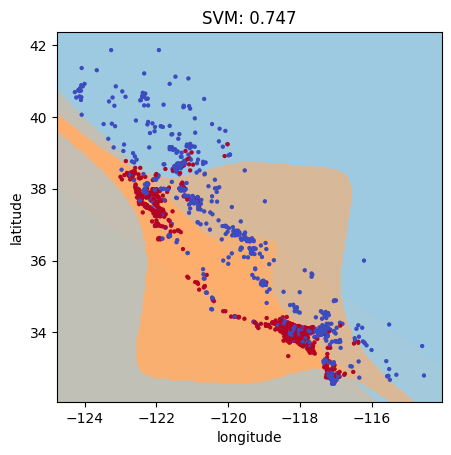

In [13]:
from sklearn.svm import SVC

DEGREES = [1, 2, 3, 5, 8]

for d in DEGREES:
    m4 = SVC(C= 1.0,kernel= "poly", degree=d)
    m4.fit(Xtr, y_train)
    
    plot_decision(m4.predict, title = f"SVM: {m3.score(Xte, y_test):.3f}")

1 0.7466666666666667
2 0.7455555555555555
3 0.7422222222222222
5 0.7488888888888889
8 0.7655555555555555


<Axes: title={'center': 'd=5: 0.75'}, xlabel='longitude', ylabel='latitude'>

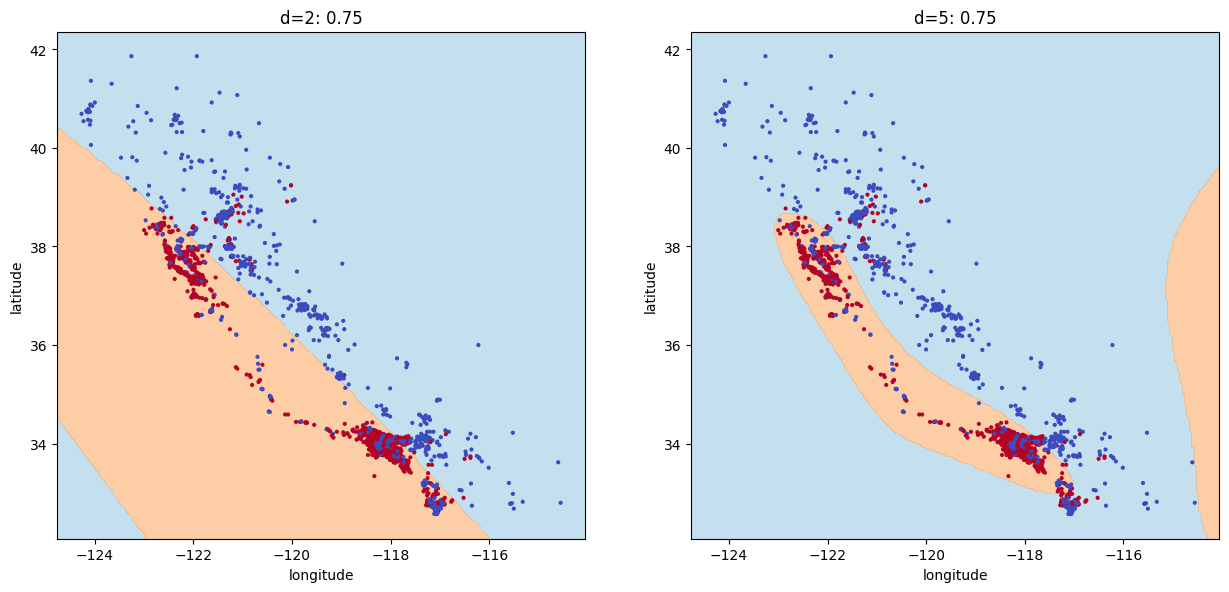

In [14]:
poly_models = {}
for d in [1, 2, 3, 5, 8]:
    poly_models[d] = SVC(kernel="poly", degree=d, coef0=1,gamma = 1).fit(Xtr, y_train)
    print(d, poly_models[d].score(Xte, y_test))
 
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
plot_decision(poly_models[2].predict, axes[0], title=f"d=2: {poly_models[2].score(Xte, y_test):.2f}")
plot_decision(poly_models[5].predict, axes[1], title=f"d=5: {poly_models[5].score(Xte, y_test):.2f}")

## Part 4 — The RBF kernel

$$k(\mathbf{x},\mathbf{z}) = \exp\left(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2\right), \qquad \gamma = \frac{1}{2\sigma^2}$$

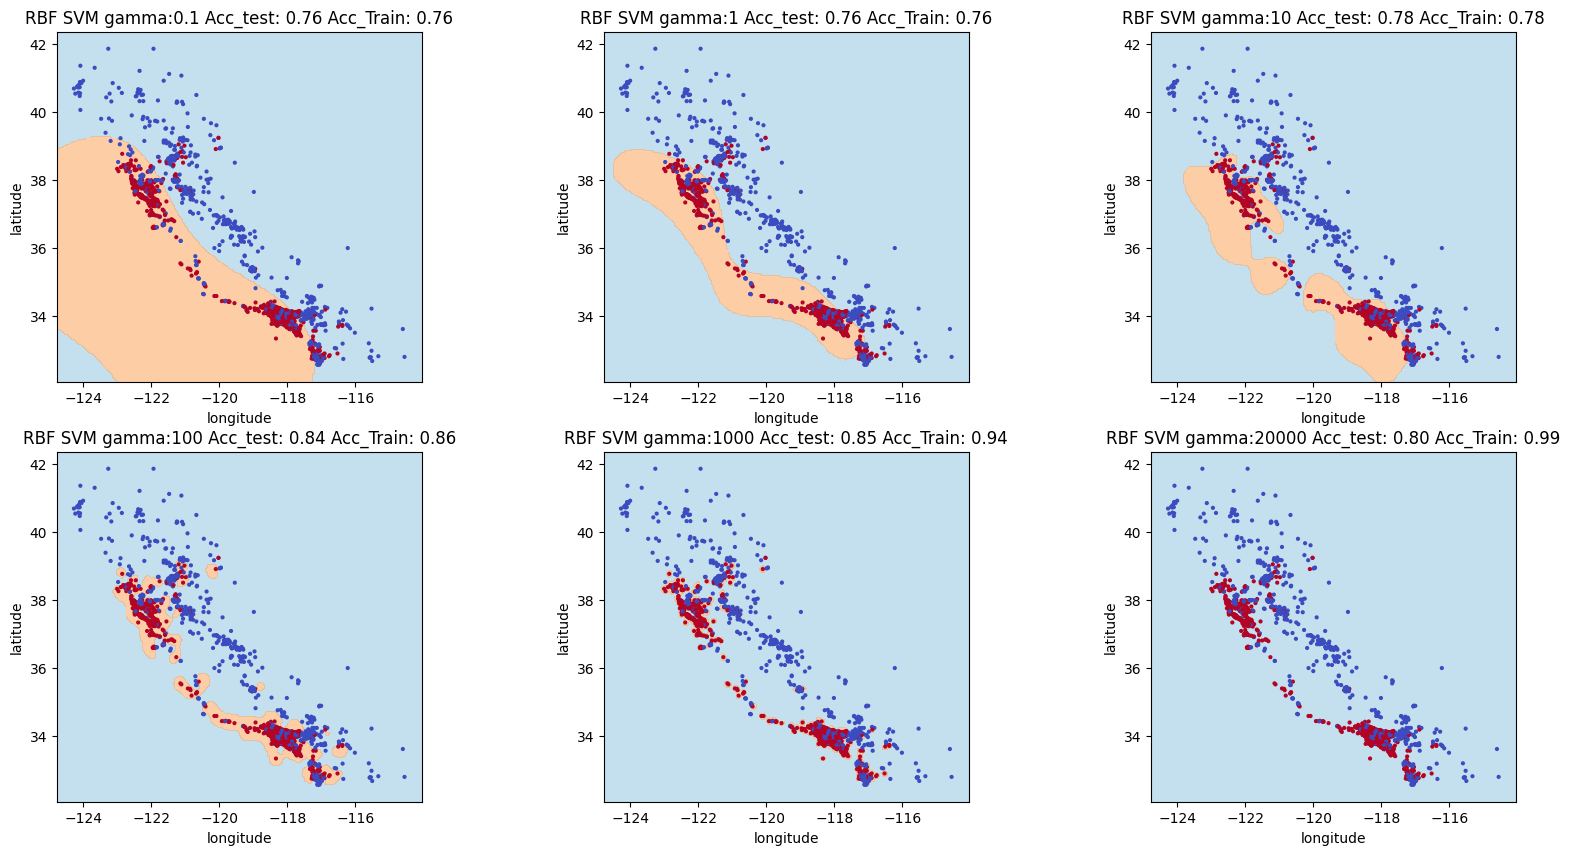

In [15]:
GAMMAS = [0.1, 1, 10, 100, 1000,20000]           # k vs. distance, distance in [0, 3]
C  = 10.0

rows = []

fig,axes = plt.subplots(2,3, figsize= (20,10))
for ax,g in zip(axes.ravel(),GAMMAS):
    model = SVC(kernel="rbf", gamma=g, C=C).fit(Xtr, y_train)
    acc = model.score(Xte, y_test)
    acc_tr = model.score(Xtr, y_train)
    # rows.append((d, Xtr.shape[1], comb(2+d,d), acc))
    plot_decision(model.predict, ax, title = f"RBF SVM gamma:{g} Acc_test: {acc:.2f} Acc_Train: {acc_tr:.2f}")
# pd.DataFrame(rows, columns= ["d", "dim H (data)", "C(n+d, d)", "test_acc"])


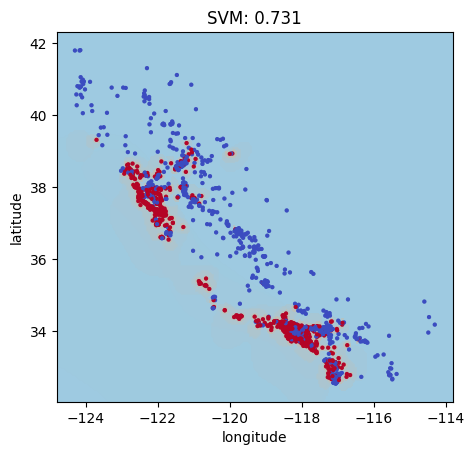

In [33]:
from sklearn.svm import SVC
GAMMAS = [0.1, 1, 10, 100, 1000, 20000]           # k vs. distance, distance in [0, 3]
C = 10

for g in GAMMAS:
    m4 = SVC(C= C,kernel= "rbf", gamma=g)
    m4.fit(Xtr, y_train)
    
    plot_decision(m4.predict, title = f"SVM: {m3.score(Xte, y_test):.3f}")

0.1 0.7377777777777778
1 0.7344444444444445
10 0.7566666666666667
100 0.8077777777777778
1000 0.8188888888888889
20000 0.76
SVC(C=10, gamma=0.1)


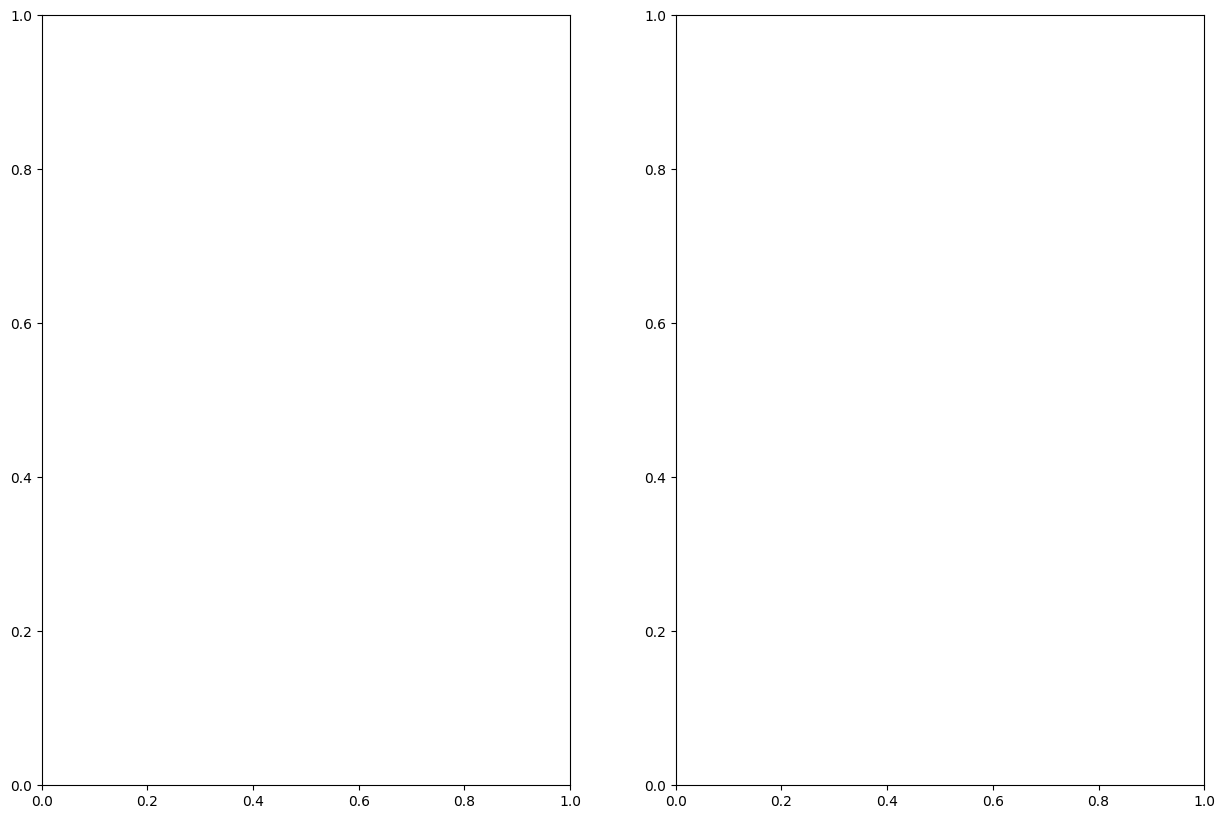

In [32]:
GAMMAS_SIMILARITY = [0.1, 1, 10, 100, 1000]           # k vs. distance, distance in [0, 3]
GAMMAS            = [0.1, 1, 10, 100, 1000, 20000]    # classifier
C                 = 10

from sklearn.svm import SVC


rbf_models = {}
for g in GAMMAS:
    rbf_models[g] = SVC(kernel="rbf", C=C,gamma = g).fit(Xtr, y_train)
    print(g, rbf_models[g].score(Xte, y_test))
 
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
# plot_decision(rbf_models[0.1].predict, axes[1], title=f"d=5: {rbf_models[5].score(Xte, y_test):.2f}")
# plot_decision(rbf_models[0.1].predict, axes[1], title=f"d=5: {rbf_models[5].score(Xte, y_test):.2f}")
print(rbf_models[0.1])

## Part 5 — Kernel families

$$k_{\text{lin}} = \mathbf{x}^\top\mathbf{z} \qquad k_{\text{poly}} = (\mathbf{x}^\top\mathbf{z}+1)^d \qquad k_{\text{RBF}} = \exp\left(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2\right)$$

In [ ]:
DEGREE = 3
GAMMA  = 50
C      = 10

## Part 6 — Soft margin

$$\min_{\mathbf{w},w_0,\boldsymbol\xi}\ \tfrac12\lVert\mathbf{w}\rVert^2 + C\sum_n\xi_n \quad\text{s.t.}\quad y_n f(\mathbf{x}_n) \ge 1-\xi_n,\ \ \xi_n\ge0$$

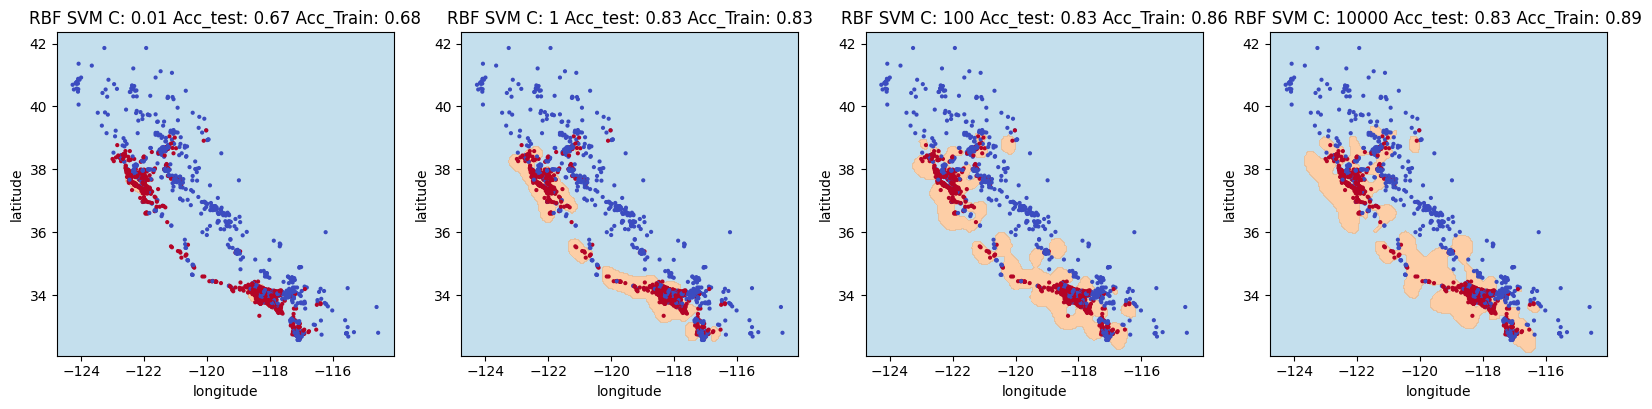

In [17]:
GAMMA = 50
CS    = [0.01, 1, 100, 10000]

fig, axes = plt.subplots(1,4, figsize= (20,5))

for ax,c in zip(axes.ravel(),CS):
    model = SVC(kernel="rbf", gamma=GAMMA, C=c).fit(Xtr, y_train)
    acc = model.score(Xte, y_test)
    acc_tr = model.score(Xtr, y_train)
    # rows.append((d, Xtr.shape[1], comb(2+d,d), acc))
    plot_decision(model.predict, ax, title = f"RBF SVM C: {c} Acc_test: {acc:.2f} Acc_Train: {acc_tr:.2f}")



## Part 7 — Final experiment

$$k_D(\mathbf{x},\mathbf{z}) = \exp\left(-\gamma\lVert\mathbf{x}_{\text{coords}}-\mathbf{z}_{\text{coords}}\rVert^2\right) + w\,\text{income}_{\mathbf{x}}\,\text{income}_{\mathbf{z}}$$

In [ ]:
CV_FOLDS = 5          # model selection on the training set; test set used once at the end

GRID = {
    "A: linear":     {"C": [0.1, 1, 10]},
    "B: polynomial": {"degree": [2, 3], "C": [1, 10]},
    "C: RBF":        {"gamma": [1, 10, 50, 200], "C": [1, 10, 100]},
    "D: k_D":        {"gamma": [50, 200], "w": [0.3, 1, 3], "C": [10]},
}